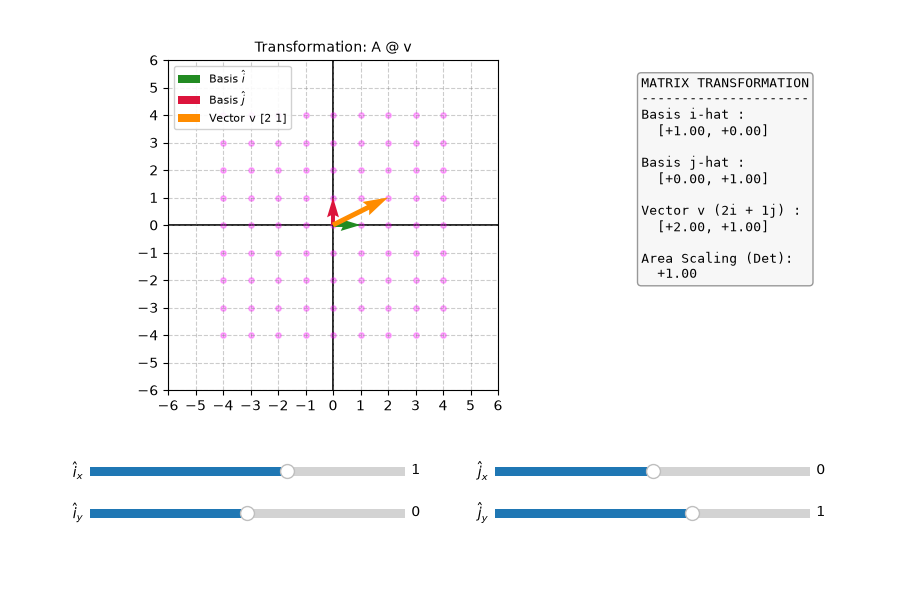

In [2]:
"""
Interactive Matrix-Vector Multiplication & Basis Vector Visualizer

by Gemini

If the sliders don't work, rerun the cell.

Incredible work. Unfortunately I did not pay attention in linear algebra, but this is helping. 
Matrix A is the i and j basis vectors where column one is i and 2 is j. The endpoints are at 1,0 and 0, 1 when space is not stretched. 
All other points on the grid are multiples of the basis vectors. When the endpoints are changed, the whole grid is transformed. 
The vector 2i + 1j was originally 2, 1, but the vector is transformed when i and j change. 
"""

%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

# 1. Base Grid Setup
min_val, max_val = -4, 5
range_values = np.arange(min_val, max_val, 1)
x, y = np.meshgrid(range_values, range_values)
grid = np.vstack([x.flatten(), y.flatten()])
v = np.array([2, 1])  # Input vector v = [x, y]

# 2. Setup Figure & Layout
fig = plt.figure(figsize=(9, 6))

# Main Plot Axes
ax = fig.add_axes([0.08, 0.35, 0.58, 0.55])  

# Text Readout Box Axes (Right side)
ax_info = fig.add_axes([0.70, 0.35, 0.25, 0.55])  
ax_info.axis('off')  # Hide axis lines/ticks for text card

# Initial Matrix A = [[i_x, j_x], [i_y, j_y]]
i_x, i_y = 1.0, 0.0
j_x, j_y = 0.0, 1.0
A = np.array([[i_x, j_x], [i_y, j_y]])

grid_transformed = A @ grid
v_transformed = A @ v

# Setup main plot limits
ticks = np.arange(-6, 7, 1)
ax.set_xlim(-6, 6)
ax.set_ylim(-6, 6)
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.axhline(0, color='black', lw=1.2, zorder=1)
ax.axvline(0, color='black', lw=1.2, zorder=1)
ax.grid(True, linestyle='--', color='gray', alpha=0.4)
ax.set_aspect('equal')

# 3. Plot Initial Artists
scatter = ax.scatter(grid_transformed[0], grid_transformed[1], color='magenta', alpha=0.3, s=15)

quiver_i = ax.quiver(0, 0, A[0, 0], A[1, 0], angles='xy', scale_units='xy', scale=1, 
                     color='forestgreen', width=0.012, zorder=5, label=r'Basis $\hat{i}$')
quiver_j = ax.quiver(0, 0, A[0, 1], A[1, 1], angles='xy', scale_units='xy', scale=1, 
                     color='crimson', width=0.012, zorder=5, label=r'Basis $\hat{j}$')
quiver_v = ax.quiver(0, 0, v_transformed[0], v_transformed[1], angles='xy', scale_units='xy', scale=1, 
                     color='darkorange', width=0.015, zorder=6, label=f'Vector v {v}')

ax.legend(loc='upper left', framealpha=0.9, fontsize=8)

# 4. Text Readout Initialization
info_text = ax_info.text(
    0.05, 0.95, "", 
    transform=ax_info.transAxes, 
    verticalalignment='top', 
    fontsize=9, 
    family='monospace',
    bbox=dict(boxstyle='round', facecolor='whitesmoke', alpha=0.8, edgecolor='gray')
)

# 5. Sliders Layout
ax_ix = fig.add_axes([0.10, 0.20, 0.35, 0.03])
ax_iy = fig.add_axes([0.10, 0.13, 0.35, 0.03])
ax_jx = fig.add_axes([0.55, 0.20, 0.35, 0.03])
ax_jy = fig.add_axes([0.55, 0.13, 0.35, 0.03])

slider_ix = Slider(ax_ix, r'$\hat{i}_x$', -4.0, 4.0, valinit=i_x)
slider_iy = Slider(ax_iy, r'$\hat{i}_y$', -4.0, 4.0, valinit=i_y)
slider_jx = Slider(ax_jx, r'$\hat{j}_x$', -4.0, 4.0, valinit=j_x)
slider_jy = Slider(ax_jy, r'$\hat{j}_y$', -4.0, 4.0, valinit=j_y)

# 6. Dynamic Update Function
def update(val):
    new_ix, new_iy = slider_ix.val, slider_iy.val
    new_jx, new_jy = slider_jx.val, slider_jy.val
    
    A_new = np.array([[new_ix, new_jx],
                      [new_iy, new_jy]])

    new_grid = A_new @ grid
    new_v = A_new @ v

    # Update Plot Vectors
    scatter.set_offsets(new_grid.T)
    quiver_i.set_UVC(new_ix, new_iy)
    quiver_j.set_UVC(new_jx, new_jy)
    quiver_v.set_UVC(new_v[0], new_v[1])

    # Update Output Coordinate Readout Text
    readout_str = (
        f"MATRIX TRANSFORMATION\n"
        f"---------------------\n"
        f"Basis i-hat :\n  [{new_ix:+.2f}, {new_iy:+.2f}]\n\n"
        f"Basis j-hat :\n  [{new_jx:+.2f}, {new_jy:+.2f}]\n\n"
        f"Vector v ({v[0]}i + {v[1]}j) :\n  [{new_v[0]:+.2f}, {new_v[1]:+.2f}]\n\n"
        f"Area Scaling (Det):\n  {np.linalg.det(A_new):+.2f}"
    )
    info_text.set_text(readout_str)
    
    ax.set_title(f"Transformation: A @ v", fontsize=10)
    fig.canvas.draw_idle()

# Attach updates to sliders
slider_ix.on_changed(update)
slider_iy.on_changed(update)
slider_jx.on_changed(update)
slider_jy.on_changed(update)

# Initial text render call
update(None)

plt.show()


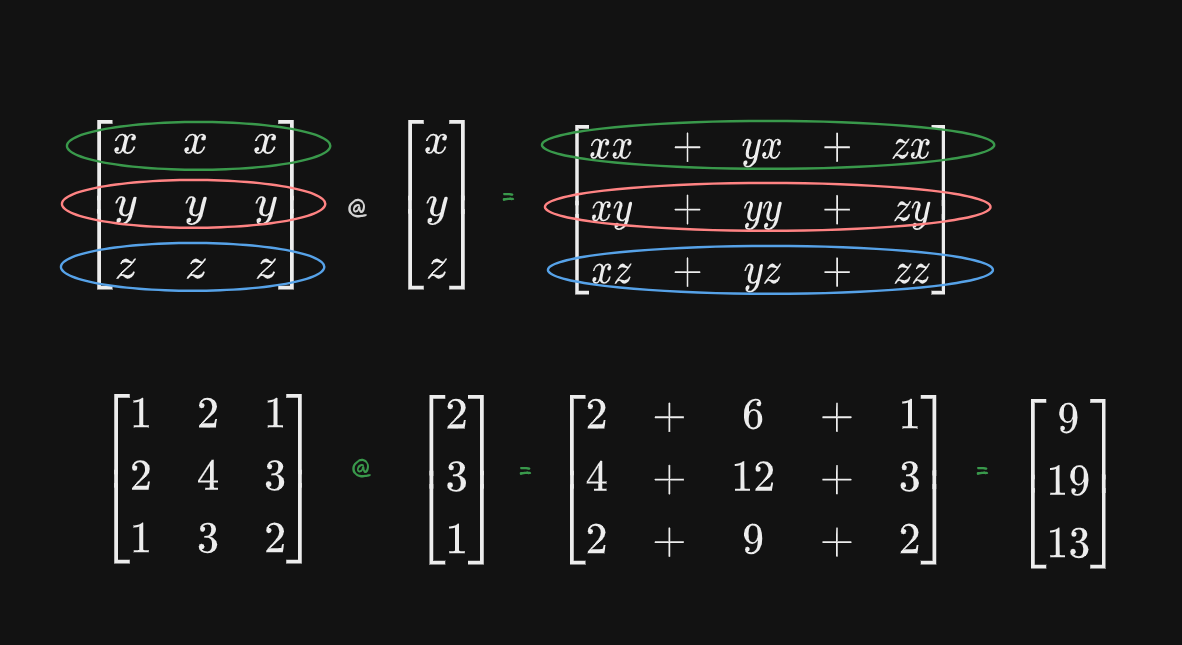